## Business Objective

Analyze retail sales data to identify trends, customer purchasing behavior, and key profitability drivers.
The goal is to generate actionable insights that can help a retail business improve sales performance,
optimize product strategy, and make data-driven decisions.


## Business Questions
1. Which regions and states generate the highest sales?
2. Which categories and sub-categories are most profitable?
3. Are there products with high sales but low or negative profit?
4. How do discounts impact profitability?
5. Which customer segments contribute the most revenue?
6. How do sales and profit change over time?


In [4]:
import pandas as pd

df = pd.read_csv("C:/Users/vidis/OneDrive/Desktop/STUFF/superstore-sales-analysis/data/raw/Sample_ Superstore.csv")
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   str    
 2   Order Date    9994 non-null   str    
 3   Ship Date     9994 non-null   str    
 4   Ship Mode     9994 non-null   str    
 5   Customer ID   9994 non-null   str    
 6   Segment       9994 non-null   str    
 7   Country       9994 non-null   str    
 8   City          9994 non-null   str    
 9   State         9994 non-null   str    
 10  Region        9994 non-null   str    
 11  Product ID    9994 non-null   str    
 12  Category      9994 non-null   str    
 13  Sub-Category  9994 non-null   str    
 14  Product Name  9994 non-null   str    
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null   float64
d

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


## Dataset Overview

The Superstore dataset contains **9,994 transaction-level records** with **19 columns**, representing orders placed by customers across different regions, product categories, and time periods.

### Data Structure
- **Rows:** 9,994 (each row represents a single order line)
- **Columns:** 19
- **Memory Usage:** ~1.4 MB (lightweight and suitable for analysis)

### Column Types
- **Numerical Features (5):**
  - `Sales` (float): Revenue generated from each order
  - `Quantity` (int): Number of units sold
  - `Discount` (float): Discount applied on the product
  - `Profit` (float): Profit earned per order
  - `Row ID` (int): Unique row identifier

- **Categorical Features (14):**
  - Order details: `Order ID`, `Order Date`, `Ship Date`, `Ship Mode`
  - Customer information: `Customer ID`, `Segment`
  - Geographic data: `Country`, `City`, `State`, `Region`
  - Product details: `Product ID`, `Category`, `Sub-Category`, `Product Name`

### Data Quality
- **No missing values** were found across all columns.
- Date columns (`Order Date`, `Ship Date`) are currently stored as strings and will be converted to datetime format during preprocessing.

### Summary Statistics (Key Insights)
- **Sales:**
  - Average sale value is approximately **₹230**
  - Sales range widely from **₹0.44 to ₹22,638**, indicating the presence of high-value orders

- **Quantity:**
  - Typical orders contain **2–5 units**, but some bulk orders go up to **14 units**

- **Discount:**
  - Discounts range from **0% to 80%**
  - Median discount is **20%**, suggesting frequent promotional pricing

- **Profit:**
  - Average profit per order is **₹28.66**
  - Profit varies significantly, with losses up to **₹6,599** and gains up to **₹8,399**
  - Indicates that high sales or high discounts do not always guarantee profitability


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [6]:
df.isnull().sum()
df.duplicated().sum()


np.int64(0)

✅ No duplicate rows found
✅ No missing values found

In [7]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Profit Margin'] = df['Profit'] / df['Sales']


### 🗓️ Order Year

- Helps perform **year-over-year comparisons** of sales and profit.
- Useful for identifying **long-term business trends**.
- Supports strategic decisions based on historical performance.

### 🗓️ Order Month

**Why it matters:**
- Helps identify **seasonal patterns and monthly trends**.
- Useful for spotting peak and low sales periods.
- Assists in planning promotions, inventory, and marketing campaigns.

### 💰 Profit Margin

**Why it matters:**
- Measures **profitability efficiency**, not just revenue.
- Helps identify products or orders that generate low or negative margins.
- Crucial for pricing strategy and cost optimization.

In [8]:
df.head()
df.describe()


,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Order Year,Order Month,Profit Margin
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,0.120314
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,-2.750000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,0.075000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,0.270000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,0.362500
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,0.500000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,0.466754


In [9]:
# Total Sales & Profit by Region
region_summary = df.groupby('Region')[['Sales','Profit']].sum()
print(region_summary)

# Total Sales & Profit by Category
category_summary = df.groupby('Category')[['Sales','Profit']].sum()
print(category_summary)

# Total Sales & Profit by Sub-Category, sorted by Profit
subcat_summary = df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values('Profit')
print(subcat_summary)


               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489
                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481
                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995
Fasteners       3024.2800    949.5182
Machines      189238.6310   3384.7569
Labels         12486.3120   5546.2540
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Furnishings    91705.1640  13059.1436
Appliances    107532.1610  18138.0054
Storage       223843.6080  21278.8264
Chairs        328449.1030  26590.1663
Binders       203412.7330  30221.7633
Paper          7

### Region-wise Sales & Profit

**Insights:**

West is the top-performing region in both sales and profit, contributing the highest revenue and margin.

East follows closely in both sales and profit, showing strong performance.

Central has moderate sales but a very low profit, suggesting higher costs or lower margins.

South has the lowest sales but a decent profit relative to its sales—profit margin is better than Central.

Business takeaway: Focus on improving profitability in Central and maintaining strong growth in West and East.

### Category-wise Sales & Profit

**Insights:**

Technology is the most profitable and highest-selling category. Clearly a core revenue driver.

Office Supplies has slightly lower sales than Furniture but generates much higher profit, indicating better margins.

Furniture has decent sales but very low profit, suggesting either high costs or heavy discounts.

Business takeaway: Consider optimizing Furniture pricing or reducing costs while investing more in Technology and Office Supplies for maximum profitability.

### Sub-Category Sales & Profit Analysis

**Insights:**

Sub-Categories with Negative Profit (Loss-Making)

Tables (-17,725), Bookcases (-3,473), Supplies (-1,189) are losing money.

Even though Tables and Bookcases have high sales, their profits are negative → high costs, excessive discounts, or low margins.

Actionable: Reassess pricing, supplier costs, or promotional strategies for these items.

High-Sales, Moderate-Profit Sub-Categories

Chairs, Phones, Storage have high sales but moderate profit margins.

They are important revenue contributors but may benefit from margin optimization.

Low-Sales, High-Profit Sub-Categories

Copiers (55,618 profit with 149,528 sales) and Accessories (41,937 profit with 167,380 sales) are more profitable relative to sales.

These have high margins, making them key focus areas for profit growth.

Niche High-Margin Items

Paper (34,054 profit on 78,479 sales), Envelopes (6,964 on 16,476 sales), Art (6,528 on 27,119 sales).

Though sales volume is low, profit margins are good.

Actionable: Consider promotional campaigns to scale these high-margin items.

General Observations

Furniture items (Tables, Bookcases, Chairs, Furnishings) are mixed: some losing, some marginally profitable.

Technology-related items (Phones, Copiers, Machines) are consistently profitable.

Office supplies like Paper, Binders, Accessories are strong performers in profit per sales.

In [10]:
df.groupby('Discount')[['Sales','Profit']].mean()

,Sales,Profit
Discount,,
0.00,226.742074,66.900292
0.10,578.397351,96.055074
0.15,529.971567,27.288298
0.20,209.076940,24.702572
0.30,454.742974,-45.679636
0.32,536.794770,-88.560656
0.40,565.134874,-111.927429
0.45,498.634000,-226.646464
0.50,892.705152,-310.703456


### Discount Impact on Sales & Profit

**Insights:**

Small discounts (0–10%) slightly increase sales while maintaining profit, making them effective for boosting revenue without hurting margins.

Moderate discounts (15–20%) show mixed results: sales are decent but profit starts declining.

High discounts (30% and above) consistently lead to negative profit, even if sales increase in some cases.

Extremely high discounts (50–80%) destroy profit and generate very little additional sales, making them unsustainable.

In [11]:
df.groupby(['Order Year','Order Month'])['Sales'].sum()

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

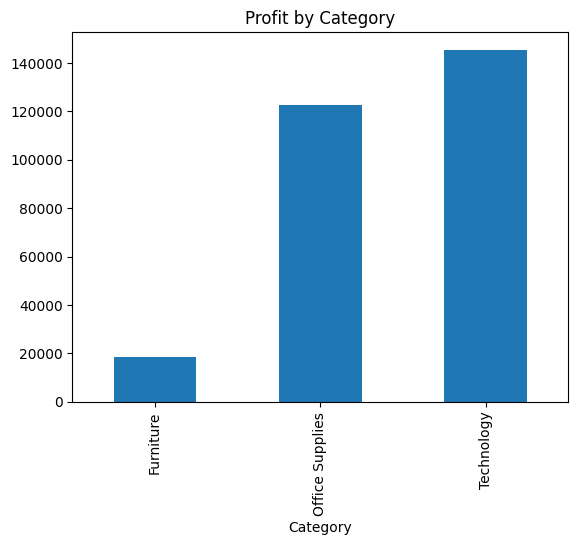

In [12]:
import matplotlib.pyplot as plt

df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Category')
plt.show()


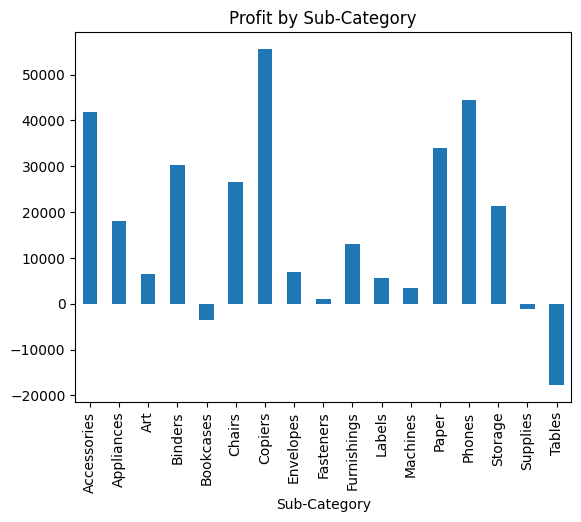

In [13]:
import matplotlib.pyplot as plt

df.groupby('Sub-Category')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Sub-Category')
plt.show()


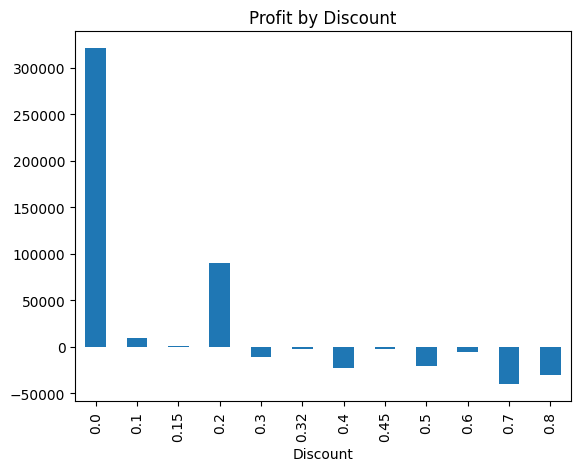

In [15]:
import matplotlib.pyplot as plt

df.groupby('Discount')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Discount')
plt.show()


## Key Insights

- Technology category shows the highest profit margins, especially in Phones and Accessories.
- Higher discounts are strongly correlated with reduced profitability and frequent losses.
- Some sub-categories (e.g., Tables, Bookcases) generate high sales volumes but consistently incur losses.
- Furniture category contributes significantly to sales but has weak profit performance compared to Technology.
